In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar tus datos
df = pd.read_csv('distances.csv')

# Preparar tensores (Usaremos D_L1 para este ejemplo)
t_data = torch.tensor(df['t'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
d_hot_data = torch.tensor(df['D_L1_h'].values, dtype=torch.float32).view(-1, 1)
d_warm_data = torch.tensor(df['D_L1_w'].values, dtype=torch.float32).view(-1, 1)

In [2]:
class MpembaPINN(nn.Module):
    def __init__(self):
        super(MpembaPINN, self).__init__()
        # Red simple: 1 entrada (t) -> 3 capas ocultas -> 1 salida (D)
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
        # Parámetro físico a descubrir: lambda (tasa de decaimiento)
        # Lo inicializamos en 1.0
        self.lmbda = nn.Parameter(torch.tensor([1.0], requires_grad=True))

    def forward(self, t):
        return self.net(t)

    def compute_physics_loss(self, t):
        d_pred = self.forward(t)
        # Diferenciación automática: dD/dt
        d_t = torch.autograd.grad(d_pred, t, grad_outputs=torch.ones_like(d_pred), 
                                  create_graph=True)[0]
        # Ecuación: dD/dt + lambda * D = 0
        residual = d_t + self.lmbda * d_pred
        return torch.mean(residual**2)

In [3]:
def train_pinn(model, t_train, d_train, epochs=10000, lr=1e-3):
    optimizer = torch.optim.Adam(list(model.parameters()), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # 1. Pérdida de Datos (ajuste al CSV)
        d_pred = model(t_train)
        loss_data = torch.mean((d_pred - d_train)**2)
        
        # 2. Pérdida Física (cumplimiento de la EDO)
        loss_physics = model.compute_physics_loss(t_train)
        
        # Total (puedes ajustar el peso de la física si es necesario)
        total_loss = loss_data + 0.1 * loss_physics
        
        total_loss.backward()
        optimizer.step()
        
        if epoch % 1000 == 0:
            print(f"Epoch {epoch} | Loss: {total_loss.item():.6f} | Lambda: {model.lmbda.item():.4f}")
    
    return model

# Entrenar una red para cada caso
print("Entrenando PINN para muestra CALIENTE...")
pinn_hot = MpembaPINN()
train_pinn(pinn_hot, t_data, d_hot_data)

print("\nEntrenando PINN para muestra TIBIA...")
pinn_warm = MpembaPINN()
train_pinn(pinn_warm, t_data, d_warm_data)

Entrenando PINN para muestra CALIENTE...
Epoch 0 | Loss: 0.269142 | Lambda: 0.9990
Epoch 1000 | Loss: 0.013277 | Lambda: 0.7984
Epoch 2000 | Loss: 0.013245 | Lambda: 0.7551
Epoch 3000 | Loss: 0.013237 | Lambda: 0.7525
Epoch 4000 | Loss: 0.013228 | Lambda: 0.7529
Epoch 5000 | Loss: 0.013227 | Lambda: 0.7529
Epoch 6000 | Loss: 0.013227 | Lambda: 0.7525
Epoch 7000 | Loss: 0.013228 | Lambda: 0.7524
Epoch 8000 | Loss: 0.013226 | Lambda: 0.7528
Epoch 9000 | Loss: 0.013226 | Lambda: 0.7528

Entrenando PINN para muestra TIBIA...
Epoch 0 | Loss: 0.334036 | Lambda: 1.0010
Epoch 1000 | Loss: 0.004159 | Lambda: 0.7309
Epoch 2000 | Loss: 0.004113 | Lambda: 0.6791
Epoch 3000 | Loss: 0.004105 | Lambda: 0.6803
Epoch 4000 | Loss: 0.004100 | Lambda: 0.6829
Epoch 5000 | Loss: 0.004090 | Lambda: 0.6840
Epoch 6000 | Loss: 0.004094 | Lambda: 0.6833
Epoch 7000 | Loss: 0.004087 | Lambda: 0.6831
Epoch 8000 | Loss: 0.004086 | Lambda: 0.6831
Epoch 9000 | Loss: 0.004086 | Lambda: 0.6829


MpembaPINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_31367/2768888681.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(t_test, d_hot_pred, 'r-', linewidth=2, label=f'PINN Hot ($\lambda$: {pinn_hot.lmbda.item():.2f})')
/tmp/ipykernel_31367/2768888681.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(t_test, d_warm_pred, 'b-', linewidth=2, label=f'PINN Warm ($\lambda$: {pinn_warm.lmbda.item():.2f})')


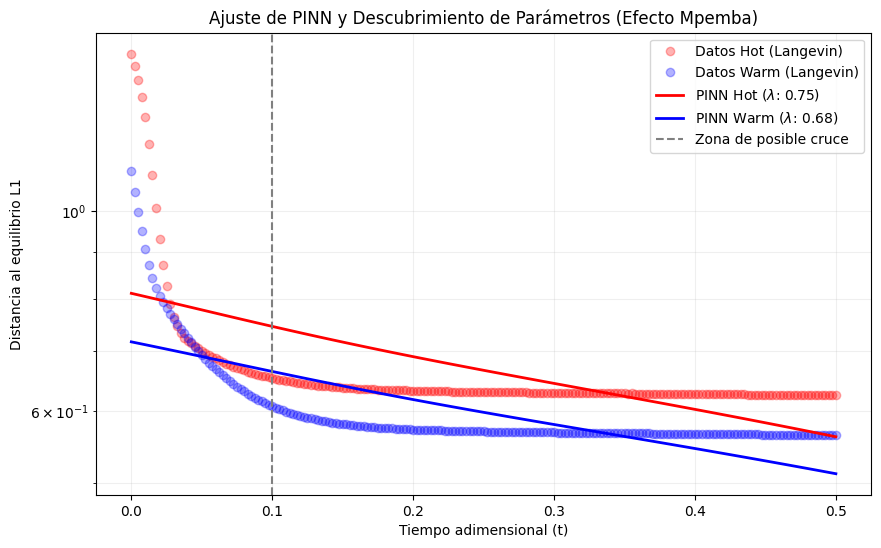

Tasa de relajación (Hot): 0.7521
Tasa de relajación (Warm): 0.6828


In [4]:
# Generar predicciones suaves
t_test = torch.linspace(0, 0.5, 100).view(-1, 1)
d_hot_pred = pinn_hot(t_test).detach().numpy()
d_warm_pred = pinn_warm(t_test).detach().numpy()

plt.figure(figsize=(10, 6))
plt.plot(df['t'], df['D_L1_h'], 'ro', alpha=0.3, label='Datos Hot (Langevin)')
plt.plot(df['t'], df['D_L1_w'], 'bo', alpha=0.3, label='Datos Warm (Langevin)')
plt.plot(t_test, d_hot_pred, 'r-', linewidth=2, label=f'PINN Hot ($\lambda$: {pinn_hot.lmbda.item():.2f})')
plt.plot(t_test, d_warm_pred, 'b-', linewidth=2, label=f'PINN Warm ($\lambda$: {pinn_warm.lmbda.item():.2f})')

plt.axvline(x=0.1, color='gray', linestyle='--', label='Zona de posible cruce')
plt.yscale('log') # Escala logarítmica para ver mejor el decaimiento
plt.xlabel('Tiempo adimensional (t)')
plt.ylabel('Distancia al equilibrio L1')
plt.title('Ajuste de PINN y Descubrimiento de Parámetros (Efecto Mpemba)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

print(f"Tasa de relajación (Hot): {pinn_hot.lmbda.item():.4f}")
print(f"Tasa de relajación (Warm): {pinn_warm.lmbda.item():.4f}")